<a href="https://colab.research.google.com/github/DibasKumarBiswal-64/End-to-End-ML-Project/blob/main/end_to_end_ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd

In [5]:
df=pd.read_csv('/content/placement.csv')

In [6]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [7]:
df.shape

(100, 4)

In [8]:
df=df.iloc[:,1:]

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

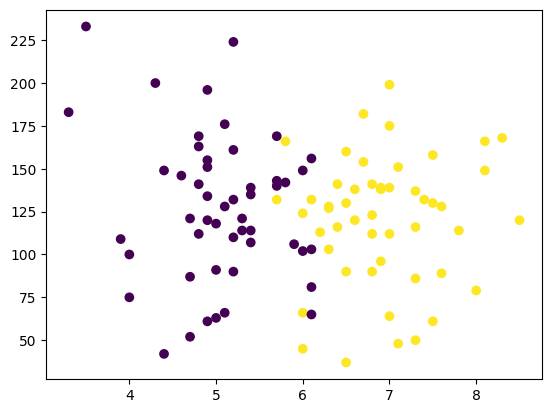

In [10]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [11]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [12]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [13]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [14]:
y.shape

(100,)

In [15]:
x.shape

(100, 2)

In [16]:
from sklearn.model_selection import  train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

### Analogy: Studying for an Exam

Imagine you're studying for a big exam. You have a textbook with many practice questions.

*   **Training Data (x_train, y_train):** These are the practice questions you study and learn from before the exam. You work through them, understand the concepts, and try to memorize the answers or methods.

*   **Testing Data (x_test, y_test):** This is the actual exam itself. It contains new questions that you haven't seen before. You can't just memorize the answers from the practice questions; you have to apply what you've learned to solve these new problems.

By testing yourself on unseen questions (the test data), you can honestly evaluate how well you've *actually* learned the material, rather than just how well you've memorized the practice questions. If you only studied the practice questions and then got tested on the same exact questions, you wouldn't know if you truly understood the material or just remembered the specific answers. The same principle applies to machine learning models!

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# New section

In [19]:
x_test

,cgpa,iq
51,4.8,141.0
30,7.6,128.0
9,5.1,66.0
79,6.5,90.0
2,5.3,121.0
78,6.1,81.0
50,3.5,233.0
57,6.5,130.0
75,4.8,169.0
73,4.9,61.0


In [20]:
x_test.shape

(10, 2)

In [21]:
y_train

,placement
26,1
48,1
44,1
69,1
84,0
...,...
11,1
23,0
88,0
65,1


In [22]:
y_test

,placement
51,0
30,1
9,0
79,1
2,0
78,0
50,0
57,1
75,0
73,0


In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler=StandardScaler()

In [25]:
x_train = scaler.fit_transform(x_train)

In [26]:
x_train

array([[ 0.84679966,  1.95459074],
       [ 0.49232539,  0.37002146],
       [ 1.28989251, -1.63017255],
       [ 2.17607821, -0.09755636],
       [-0.30524174,  1.17529437],
       [ 0.84679966,  0.39599801],
       [-1.0141903 , -0.09755636],
       [-0.03938603, -1.50028982],
       [-1.0141903 ,  0.81162274],
       [ 0.75818109,  0.39599801],
       [-0.74833459, -0.35732182],
       [ 0.04923254, -0.53915764],
       [-0.1280046 , -0.461228  ],
       [ 0.84679966, -1.55224291],
       [-2.43208741,  1.53896601],
       [ 0.04923254, -1.52626637],
       [-1.10280886, -0.30536872],
       [ 1.11265537, -1.91591455],
       [-0.57109745,  0.39599801],
       [ 1.82160393,  0.65576346],
       [-0.74833459,  0.96748201],
       [ 1.37851108, -0.90282927],
       [ 0.66956253, -0.87685273],
       [ 1.28989251,  0.88955237],
       [-1.280046  ,  0.57783383],
       [ 1.55574822, -0.25341563],
       [-0.74833459, -0.87685273],
       [ 0.04923254,  0.21416219],
       [ 0.93541823,

In [27]:
x_test=scaler.transform(x_test)

In [28]:
x_test

array([[-1.10280886,  0.4479511 ],
       [ 1.37851108,  0.110256  ],
       [-0.83695316, -1.50028982],
       [ 0.40370682, -0.87685273],
       [-0.65971602, -0.07157981],
       [ 0.04923254, -1.11064164],
       [-2.25485027,  2.83779329],
       [ 0.40370682,  0.1622091 ],
       [-1.10280886,  1.17529437],
       [-1.0141903 , -1.63017255]])

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
clf = LogisticRegression()

In [31]:
clf.fit(x_train,y_train)

LogisticRegression()

In [32]:
y_pred = clf.predict(x_test)

In [33]:
y_test

,placement
51,0
30,1
9,0
79,1
2,0
78,0
50,0
57,1
75,0
73,0


In [34]:
from sklearn.metrics import accuracy_score

In [35]:
accuracy_score(y_test,y_pred)

0.9

In [36]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

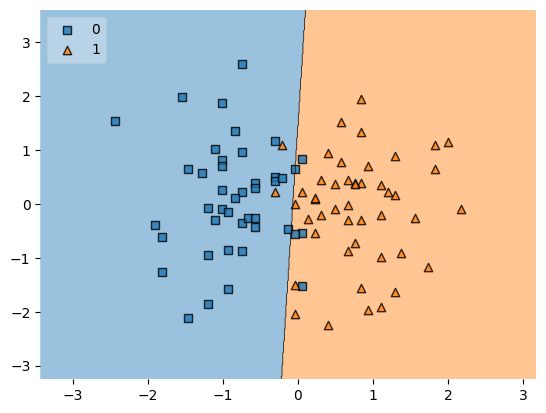

In [37]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [38]:
import pickle

In [39]:
pickle.dump(clf,open('model.pkl','wb'))